In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from mpl_toolkits.mplot3d import Axes3D

In [9]:
# Import Random Training Data
observations = 1000

xs = np.random.uniform(low=-10, high=10, size=(observations,1))
zs = np.random.uniform(-10,10,(observations,1))

inputs = np.column_stack((xs,zs))

print(inputs.shape)
inputs

(1000, 2)


array([[ 3.93374978,  8.24479087],
       [-8.46037176, -6.62175974],
       [-4.61374055,  4.18662637],
       ...,
       [-9.44185212,  7.62036619],
       [-1.97091441,  2.32654282],
       [-1.404124  ,  0.80333584]])

In [10]:
# Target
noise = np.random.uniform(-1,1,(observations,1))

targets = 2*xs - 3*zs + 5 + noise
print(targets.shape)

(1000, 1)


In [ ]:
# Plot Training Data
targets = targets.reshape(observations,)

fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)

ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('targets')

ax.view_init(azim=100)
plt.show()

targets = targets.reshape(observations,1)

In [11]:
# Set First Bias and weights
init_range = 0.1

weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)

print(weights)
print(biases)

[[ 0.04001765]
 [-0.01063591]]
[0.03248562]


In [17]:
# Set Learning Late
learning_rate = 1

In [18]:
# Training Model
for i in range(200):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas**2)/2/observations

  print(loss)

  deltas_scaled = deltas/ observations

  weights = weights - learning_rate * np.dot(inputs.T,deltas_scaled)
  biases = biases - learning_rate * np.sum(deltas_scaled)


0.16987189985689316
0.16987089189408966
0.16987089189305704
0.16987089189305712
0.1698708918930571
0.16987089189305754
0.16987089189350307
0.16987089235591962
0.16987137514836323
0.17037839514836933
0.7058493511647737
569.2688168477483
607333.9755945317
651208906.119963
701313267934.9427
758306181778952.5
8.229251436037372e+17
8.959947091751069e+20
9.784363688069018e+23
1.0712795604570138e+27
1.1756739513574509e+30
1.2929031334840595e+33
1.424399894853334e+36
1.5717632472286378e+39
1.73677741154604e+42
1.921432985475458e+45
2.1279505432887052e+48
2.3588069469165978e+51
2.6167646790812086e+54
2.904904545064872e+57
3.2266621294455476e+60
3.585868438458657e+63
3.9867952080612464e+66
4.4342054128596805e+69
4.933409572466647e+72
5.4903285203026915e+75
6.111563376159611e+78
6.804473548899241e+81
7.57726369047518e+84
8.439080628157217e+87
9.400121419655856e+90
1.047175380717854e+94
1.1666650492852314e+97
1.2998938821145669e+100
1.4484367635845006e+103
1.6140493281934903e+106
1.798688694879147

/tmp/ipython-input-3942058622.py:6: RuntimeWarning: overflow encountered in square
  loss = np.sum(deltas**2)/2/observations
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [19]:
print(weights)
print(biases)

[[-3.77108220e+288]
 [ 2.22727968e+288]]
[2.00564235e+286]


<function matplotlib.pyplot.show(close=None, block=None)>

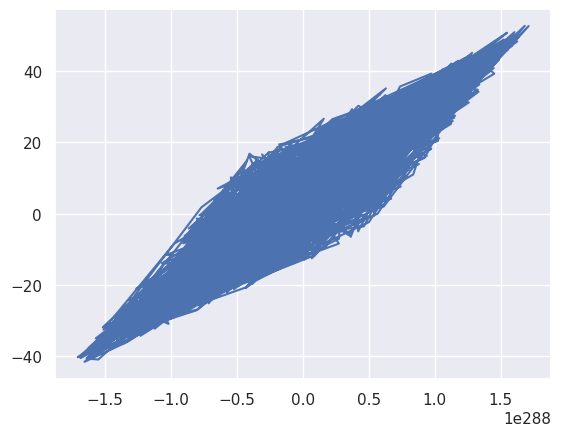

In [20]:
plt.plot(outputs,targets)
plt.show